**Unsupervised**

In [10]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

notebook_dir = Path().resolve()
project_root = notebook_dir
for _ in range(6):
    if (project_root / 'requirements.txt').exists(): break
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))
from data_ai.config import DATA_PROCESSED_DIR, ARTIFACT_MODELS_DIR, ARTIFACT_REPORTS_DIR

df = pd.read_csv(DATA_PROCESSED_DIR / 'cleaned_car_data.csv')
print(f'Loaded {len(df)} rows')
df.head(3)

Loaded 735 rows


,id,car_id,event,timestamp,hit,speed,isMoving,hitStrength,orientation,speed_enc,...,orientation_enc,event_enc,hit_int,isMoving_int,damage_score,t_sec,roll_hit_rate,roll_moving_rate,roll_damage,window_10s
0,1,2,speed,2026-05-20 09:51:18.856883,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.000000,0.0,0.0,0.0,0
1,2,2,speed,2026-05-20 09:51:19.154162,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.297279,0.0,0.0,0.0,0
2,3,2,speed,2026-05-20 09:51:19.159086,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.302203,0.0,0.0,0.0,0


**Feature selection**

In [11]:
CLUSTER_FEATURES = ['speed_enc', 'isMoving_int', 'orientation_enc','hitStrength_enc', 'hit_int']

X = df[CLUSTER_FEATURES].copy()
X['speed_enc']       = X['speed_enc'].fillna(-1)
X['orientation_enc'] = X['orientation_enc'].fillna(-1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix: {X_scaled.shape}')
pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES).describe().round(2)

Feature matrix: (735, 5)


,speed_enc,isMoving_int,orientation_enc,hitStrength_enc,hit_int
count,735.00,735.00,735.00,735.00,735.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.81,-0.33,-0.14,-0.20,-0.20
25%,-0.01,-0.33,-0.14,-0.20,-0.20
50%,-0.01,-0.33,-0.14,-0.20,-0.20
75%,-0.01,-0.33,-0.14,-0.20,-0.20
max,5.38,3.03,10.21,5.02,5.02


**elbow method (choosing K)**

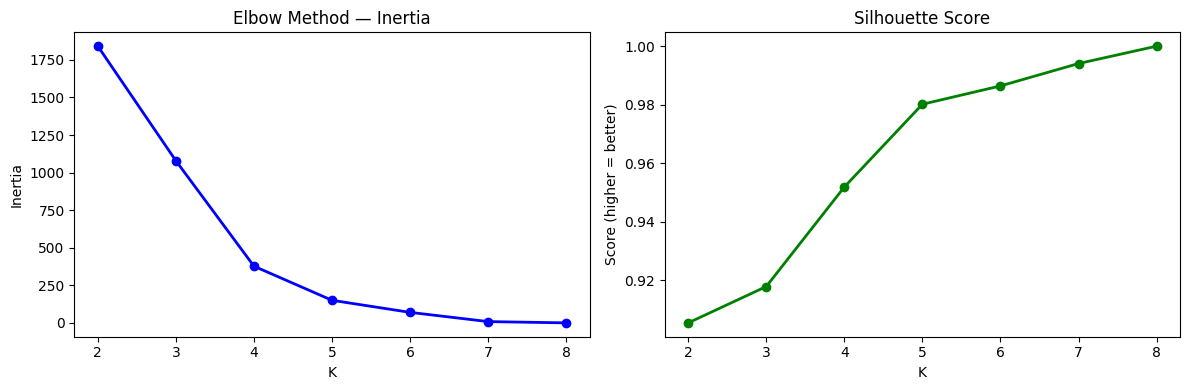

Best K by silhouette: 8


In [12]:
inertias   = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set(title='Elbow Method — Inertia', xlabel='K', ylabel='Inertia')
axes[1].plot(list(K_range), silhouettes, 'go-', linewidth=2)
axes[1].set(title='Silhouette Score', xlabel='K', ylabel='Score (higher = better)')
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'elbow_silhouette.png', dpi=120)
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best K by silhouette: {best_k}')

**fit KMeans**

In [13]:
K = 4  # u can adjust based on elbow/silhouette above

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print(f'Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    663
1     28
2     16
3     28
Name: count, dtype: int64


**PCA visual (2 components)**

Variance explained: PC1=51.5%  PC2=26.5%


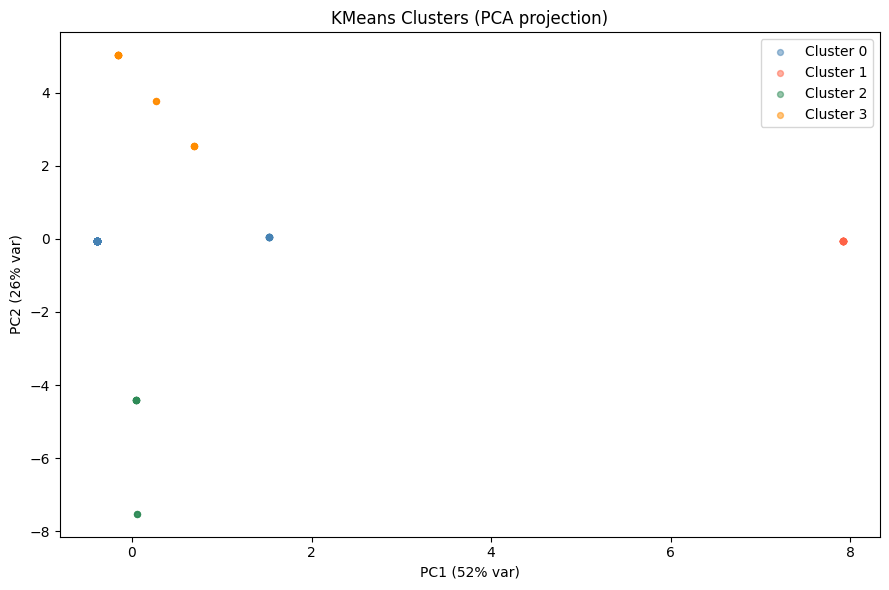

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 6))
palette = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple', 'goldenrod', 'brown']

for c in range(K):
    mask = df['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],color=palette[c], label=f'Cluster {c}', alpha=0.5, s=18
        )

ax.set(title='KMeans Clusters (PCA projection)',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'clusters_pca.png', dpi=120)
plt.show()

**Interpret clusters**

In [15]:
# Fill NaN in df so the profile table doesn't show blanks
df['speed_enc']       = df['speed_enc'].fillna(-1)
df['orientation_enc'] = df['orientation_enc'].fillna(-1)

cluster_profile = (
    df.groupby('cluster')[CLUSTER_FEATURES + ['damage_score', 'event']]
    .agg({
        'speed_enc'       : 'mean',
        'isMoving_int'    : 'mean',
        'orientation_enc' : 'mean',
        'hit_int'         : 'mean',
        'hitStrength_enc' : 'mean',
        'damage_score'    : 'sum',
        'event'           : 'count'
    })
    .rename(columns={'event': 'n_rows'})
)
cluster_profile.columns = ['avg_speed','moving_rate','avg_orient','hit_rate','avg_hit_strength','total_damage','n_rows']
cluster_profile = cluster_profile.round(3)
print(cluster_profile.to_string())

         avg_speed  moving_rate  avg_orient  hit_rate  avg_hit_strength  total_damage  n_rows
cluster                                                                                      
0           -0.024        0.024       -1.00       0.0               0.0             0     663
1           -1.000        1.000       -1.00       1.0               1.0            28      28
2           -1.000        0.000        0.25       0.0               0.0             0      16
3            2.286        1.000       -1.00       0.0               0.0             0      28


**Heatmap**

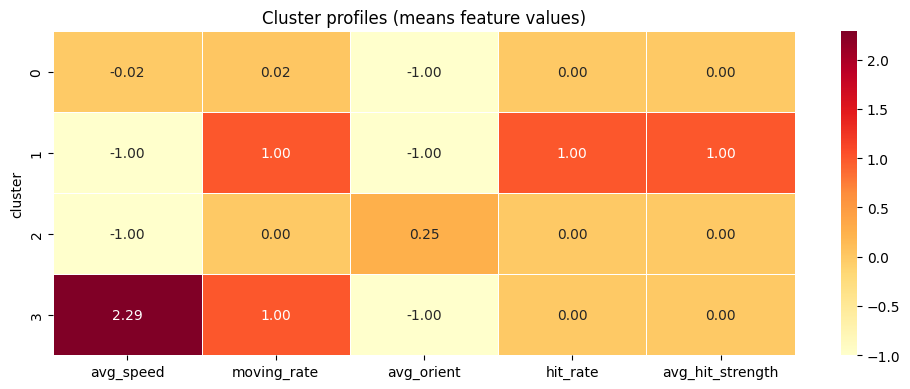

In [16]:
fig, ax = plt.subplots(figsize=(10,4))
profile_norm = cluster_profile.drop(columns=['n_rows', 'total_damage'])
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Cluster profiles (means feature values)')
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'cluster_profiles.png', dpi=120)
plt.show()

Cluster label distribution:
cluster_label
Stationary — safe        663
Moving fast — no hits     28
Hit event                 28
Slow / recovering         16
Name: count, dtype: int64


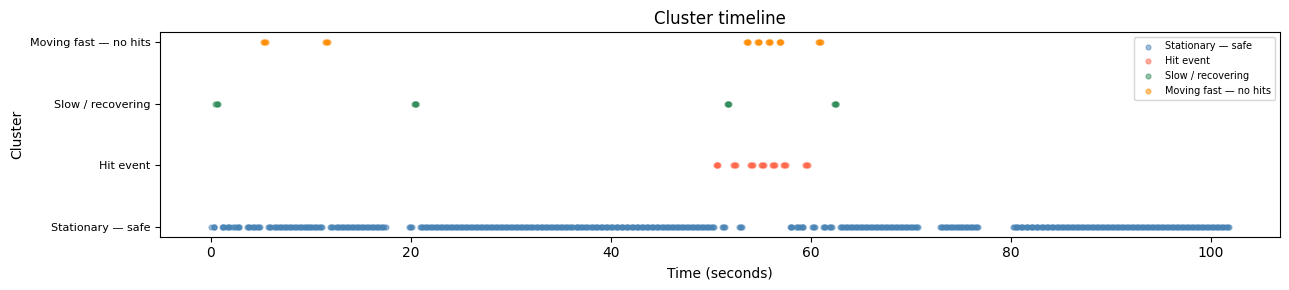

In [17]:
# Assign human-readable labels based on profile
# (Update these after inspecting the profile table above)
CLUSTER_LABELS = {
    0: 'Stationary — safe',
    1: 'Hit event',              
    2: 'Slow / recovering',       
    3: 'Moving fast — no hits',   
}

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
print('Cluster label distribution:')
print(df['cluster_label'].value_counts())

# Plot_timeline
fig, ax = plt.subplots(figsize=(13, 3))
for c, label in CLUSTER_LABELS.items():
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 't_sec'], [c]*mask.sum(), color=palette[c], label=label, alpha=0.5, s=12)
ax.set(title='Cluster timeline', xlabel='Time (seconds)', ylabel='Cluster')
ax.set_yticks(list(CLUSTER_LABELS.keys()))
ax.set_yticklabels(list(CLUSTER_LABELS.values()), fontsize=8)
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'cluster_timeline.png', dpi=120)
plt.show()

**Save Model**

In [18]:
joblib.dump(km,     ARTIFACT_MODELS_DIR / 'kmeans_behaviour.pkl')
joblib.dump(scaler, ARTIFACT_MODELS_DIR / 'scaler_behaviour.pkl')
joblib.dump(pca,    ARTIFACT_MODELS_DIR / 'pca_behaviour.pkl')
print('Models saved.')

Models saved.
